In [17]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [18]:
df=pd.read_csv(r"C:\Users\Expert\Downloads\Heart_dataset.csv", index_col=0)
df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [19]:
df.shape

(303, 14)

In [20]:
df.dtypes

Age            int64
Sex            int64
ChestPain     object
RestBP         int64
Chol           int64
Fbs            int64
RestECG        int64
MaxHR          int64
ExAng          int64
Oldpeak      float64
Slope          int64
Ca           float64
Thal          object
AHD           object
dtype: object

In [21]:
df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [23]:
df.isnull().sum()

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64

In [41]:
#  if needed DATA INTEGRATION

df_copy = df.copy()

integrated_data = pd.concat([df, df_copy])

print("Integrated Dataset Shape:", integrated_data.shape)

Integrated Dataset Shape: (606, 14)


In [42]:
from sklearn.preprocessing import LabelEncoder

In [43]:
mean_val= df['Ca'].mean()
df['Ca'].fillna(mean_val,inplace=True)

C:\Users\Expert\AppData\Local\Temp\ipykernel_19640\3637216482.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ca'].fillna(mean_val,inplace=True)


In [44]:
le = LabelEncoder()
df['Thal'] = le.fit_transform(df['Thal'])
df['ChestPain'] = le.fit_transform(df['ChestPain'])
df['AHD'] = le.fit_transform(df['AHD'])

In [45]:
df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,3,145,233,1,2,150,0,2.3,3,0.000000,0,0
2,67,1,0,160,286,0,2,108,1,1.5,2,3.000000,1,1
3,67,1,0,120,229,0,2,129,1,2.6,2,2.000000,2,1
4,37,1,1,130,250,0,0,187,0,3.5,3,0.000000,1,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,3,110,264,0,0,132,0,1.2,2,0.000000,2,1
300,68,1,0,144,193,1,0,141,0,3.4,2,2.000000,2,1
301,57,1,0,130,131,0,0,115,1,1.2,2,1.000000,2,1
302,57,0,2,130,236,0,2,174,0,0.0,2,1.000000,1,1


In [46]:
mode_val = df['Thal'].mode()
df['Thal'].fillna(mode_val, inplace=True)

C:\Users\Expert\AppData\Local\Temp\ipykernel_19640\3006955743.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Thal'].fillna(mode_val, inplace=True)


In [47]:
df.isnull().sum()

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           0
Thal         0
AHD          0
dtype: int64

In [48]:
X = df.drop("AHD", axis=1)
y = df["AHD"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
# DATA TRANSFORMATION

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
# DATA MODEL BUILDING
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [52]:
y_pred = log_model.predict(X_test_scaled)

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8524590163934426

Confusion Matrix:
 [[24  5]
 [ 4 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



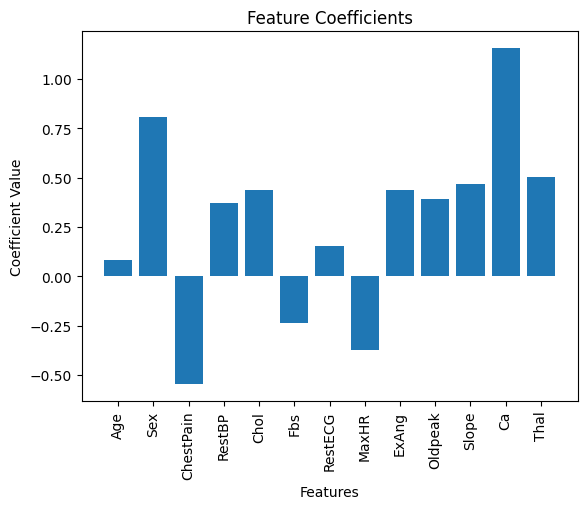

In [54]:
coefficients = log_model.coef_[0]
features = X.columns

plt.figure()
plt.bar(features, coefficients)
plt.xticks(rotation=90)
plt.title("Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.show()

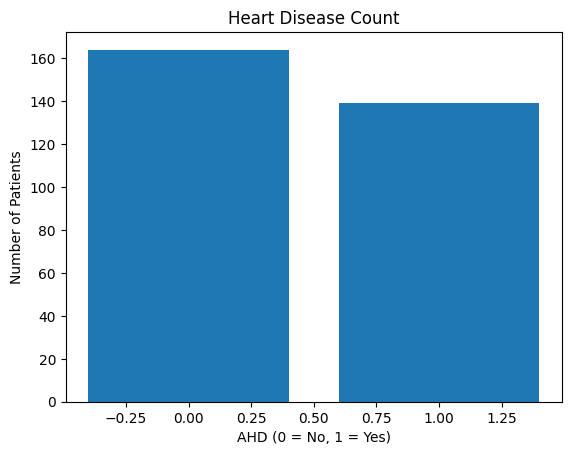

In [55]:
plt.figure()
counts = df["AHD"].value_counts()

plt.bar(counts.index, counts.values)
plt.title("Heart Disease Count")
plt.xlabel("AHD (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

In [58]:
X.columns

Index(['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR',
       'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal'],
      dtype='object')

In [61]:
# ERROR CORRECTION FOR USER INPUT

try:

    print("Enter Patient Details:")

    age = float(input("Age: "))
    sex = int(input("Sex (1=Male, 0=Female): "))
    chestpain = int(input("Chest Pain Type (numeric): "))
    restbp = float(input("Resting BP: "))
    chol = float(input("Cholesterol: "))
    fbs = int(input("Fasting Blood Sugar (1=True, 0=False): "))
    restecg = int(input("Rest ECG: "))
    maxhr = float(input("Max Heart Rate: "))
    exang = int(input("Exercise Induced Angina (1=Yes, 0=No): "))
    oldpeak = float(input("Oldpeak: "))
    slope = int(input("Slope: "))
    ca = float(input("Number of vessels (ca): "))
    thal = int(input("Thal value: "))

    user_data = pd.DataFrame([[age, sex, chestpain, restbp, chol, fbs,
                               restecg, maxhr, exang, oldpeak,
                               slope, ca, thal]],
                             columns=X.columns)

    user_scaled = scaler.transform(user_data)

    prediction = log_model.predict(user_scaled)

    if prediction[0] == 1:
        print("Patient HAS Heart Disease")

    else:
        print("Patient DOES NOT have Heart Disease")

except ValueError:
    print("Please enter numeric values only")

except Exception as e:
    print("Error:", e)

Enter Patient Details:


Age:  67
Sex (1=Male, 0=Female):  1
Chest Pain Type (numeric):  0
Resting BP:  160
Cholesterol:  286
Fasting Blood Sugar (1=True, 0=False):  1
Rest ECG:  0
Max Heart Rate:  108
Exercise Induced Angina (1=Yes, 0=No):  1
Oldpeak:  2.5
Slope:  1
Number of vessels (ca):  3
Thal value:  3


Patient HAS Heart Disease
